In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import ConfusionMatrixDisplay
from utils import audit_utils

In [2]:
device = audit_utils.setup_env()

internal_path = 'Case3Dataset/test_internal'
external_path = 'Case3Dataset/test_external'

test_internal_loader, test_external_loader, test_internal_dataset, test_external_dataset = audit_utils.get_dataloaders(
    internal_path, external_path, batch_size=16, num_workers=1
)

Using device: cpu


In [3]:
resnet_frozen = audit_utils.setup_model(2, "resnet_frozen_best_case3.pth", device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [4]:
all_predictions, all_labels = audit_utils.evaluate_model(resnet_frozen, test_internal_loader, test_external_loader, device)

for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 19/19 [00:07<00:00,  2.49it/s]

internal set - Accuracy: 0.973
external set - Accuracy: 0.593



===== INTERNAL SET =====
Accuracy : 0.973
Precision: 0.973
Recall   : 0.973
F1-score : 0.973


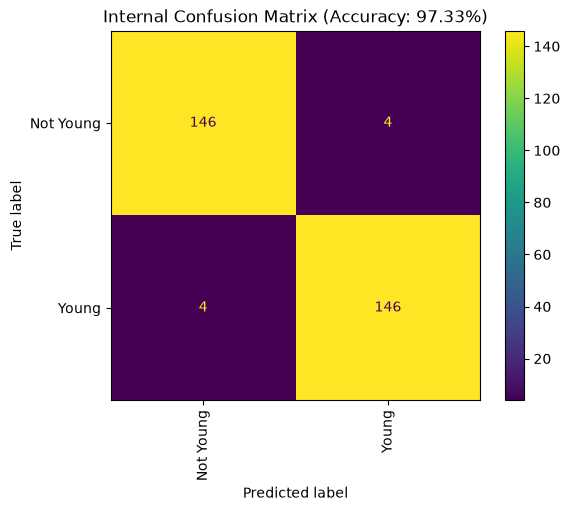


===== EXTERNAL SET =====
Accuracy : 0.593
Precision: 0.561
Recall   : 0.853
F1-score : 0.677


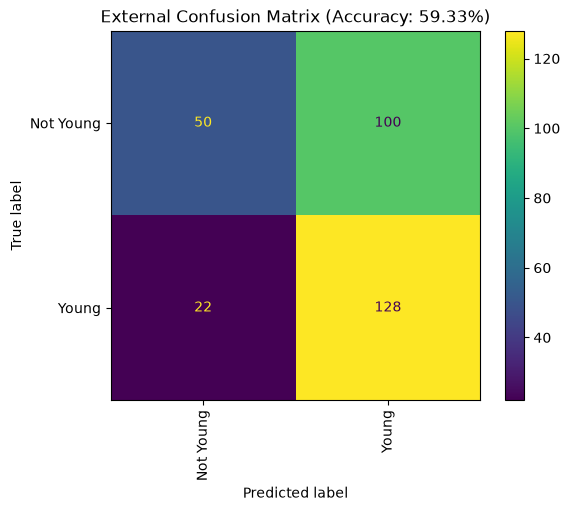

In [5]:
threshold = 0.5
for split in ['internal', 'external']:
    labels = all_labels[split]
    probs_young = all_predictions[split][:, 1]
    preds = probs_young >= threshold

    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = audit_utils.compute_metrics(labels, probs_young, threshold=threshold)

    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['Not Young', 'Young'], xticks_rotation='vertical'
    )
    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
    plt.savefig(f'plot/case3_cm_{split}.png')
    plt.show()

External Set Expected Calibration Error (ECE): 0.3036


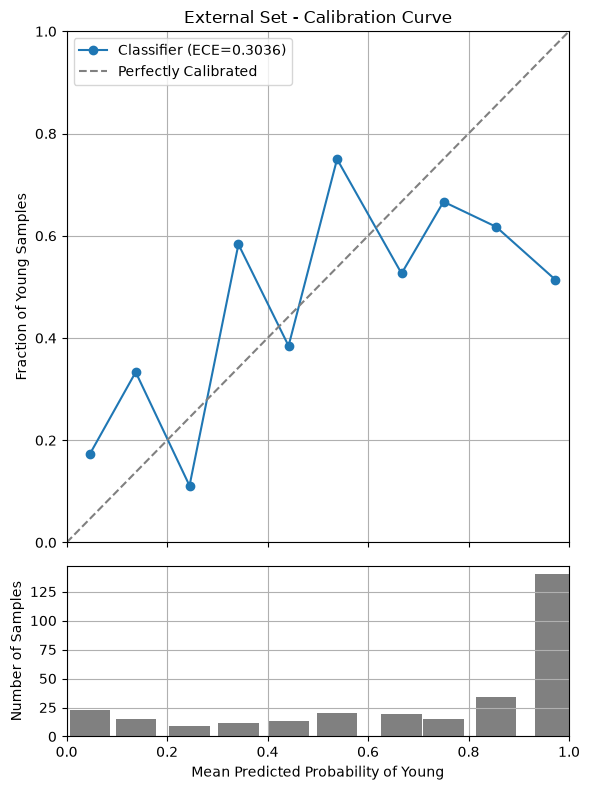

In [6]:
# Calibration Curve and ECE
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)

labels = all_labels['external'].astype(bool)
probs_young = all_predictions['external'][:,1]

bin_indices = np.digitize(probs_young, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

bin_true_frac = []
bin_mean_prob = []
bin_counts = []

for i in range(n_bins):
    mask = bin_indices == i
    mask_sum = np.sum(mask)
    bin_counts.append(mask_sum)
    if mask_sum > 0:
        bin_true_frac.append(np.mean(labels[mask]))
        bin_mean_prob.append(np.mean(probs_young[mask]))
    else:
        bin_true_frac.append(np.nan)
        bin_mean_prob.append(np.nan)

bin_true_frac = np.array(bin_true_frac)
bin_mean_prob = np.array(bin_mean_prob)
bin_counts = np.array(bin_counts)

# Calculate ECE
ece = audit_utils.calculate_ece(labels, probs_young, n_bins=10)
print(f"External Set Expected Calibration Error (ECE): {ece:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8), sharex=True, gridspec_kw={'height_ratios':[3, 1]})

ax1.plot(bin_mean_prob, bin_true_frac, marker='o', label=f'Classifier (ECE={ece:.4f})')
ax1.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
ax1.set_ylabel('Fraction of Young Samples')
ax1.set_title('External Set - Calibration Curve')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True)
ax1.legend()

ax2.bar(bin_mean_prob, bin_counts, width=0.08, color='gray')
ax2.set_xlabel('Mean Predicted Probability of Young')
ax2.set_ylabel('Number of Samples')
ax2.set_xlim(0, 1)
ax2.grid(True)

plt.tight_layout()
plt.savefig('plot/case3_calibration.png')
plt.show()

In [7]:
# High-Confidence Bypass
labels = all_labels['external']
probs_young = all_predictions['external'][:, 1]
high_conf_mask = probs_young >= 0.9

high_conf_probs = probs_young[high_conf_mask]
high_conf_labels = labels[high_conf_mask]

high_conf_total = len(high_conf_labels)
high_conf_correct = np.sum(high_conf_labels == 1)
high_conf_incorrect = np.sum(high_conf_labels == 0)
high_conf_accuracy = high_conf_correct / high_conf_total if high_conf_total > 0 else 0

print("===== EXTERNAL HIGH-CONFIDENCE BYPASS =====")
print(f"Total bypassed predictions : {high_conf_total}")
print(f"Correct Young predictions  : {high_conf_correct}")
print(f"Incorrect Not Young samples: {high_conf_incorrect}")
print(f"Bypass accuracy            : {high_conf_accuracy:.3f}")

===== EXTERNAL HIGH-CONFIDENCE BYPASS =====
Total bypassed predictions : 140
Correct Young predictions  : 72
Incorrect Not Young samples: 68
Bypass accuracy            : 0.514


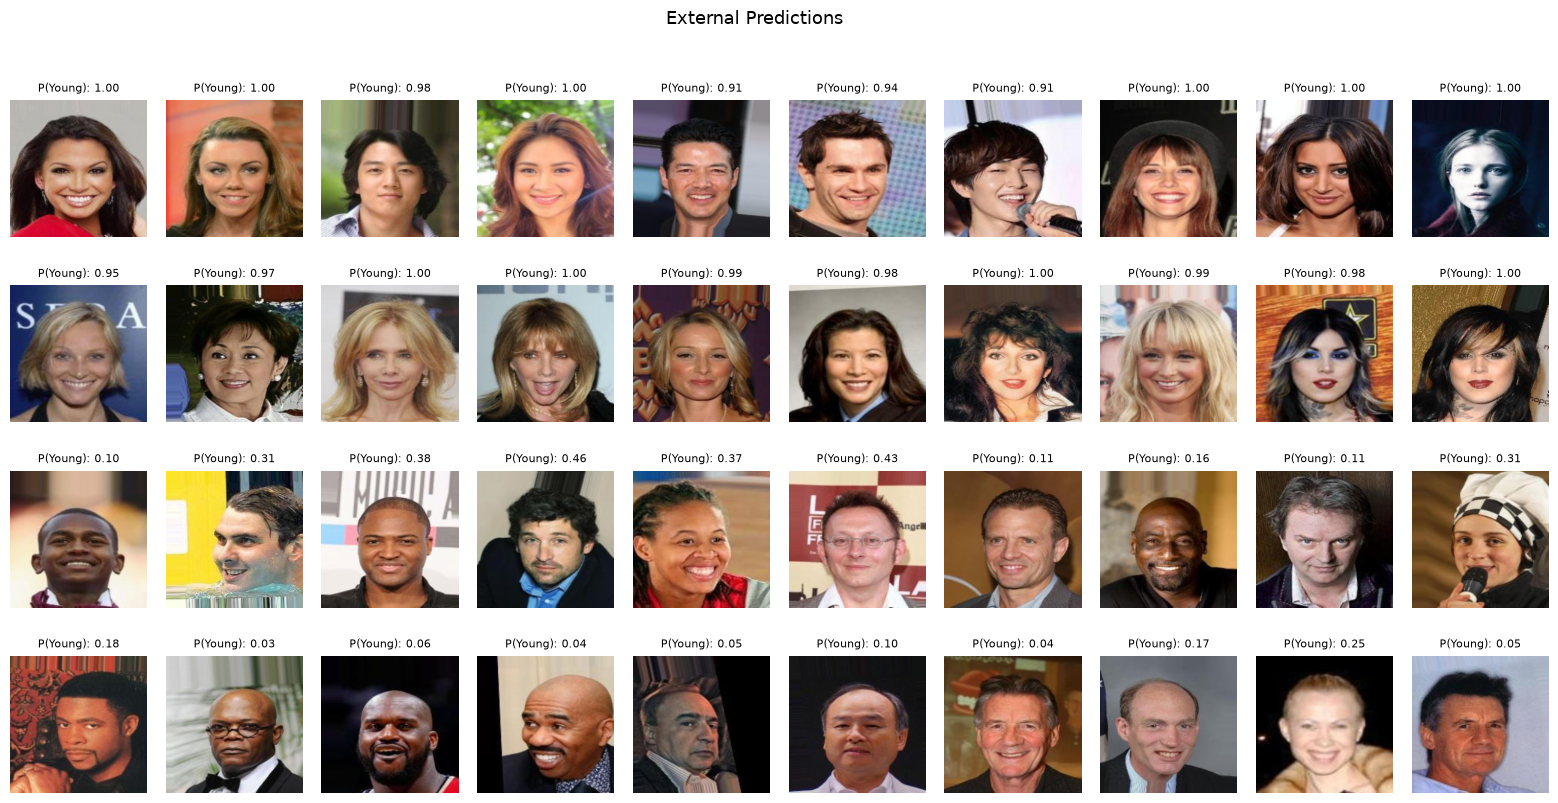

In [8]:
high_conf_young = np.where((labels == 1) & (probs_young >= 0.9))[0]
high_conf_not_young = np.where((labels == 0) & (probs_young >= 0.9))[0]
low_prob_young = np.where((labels == 1) & (probs_young < 0.5))[0]
low_prob_not_young = np.where((labels == 0) & (probs_young < 0.5))[0]

np.random.seed(0)
selected_young = np.random.choice(high_conf_young, 10, replace=False)
selected_not_young = np.random.choice(high_conf_not_young, 10, replace=False)
selected_low_young = np.random.choice(low_prob_young, 10, replace=False)
selected_low_not_young = np.random.choice(low_prob_not_young, 10, replace=False)

fig, axes = plt.subplots(4, 10, figsize=(20, 9))

for col, idx in enumerate(selected_young):
    image, _ = test_external_dataset[idx]
    axes[0, col].imshow(audit_utils.denormalize_image(image))
    axes[0, col].set_title(f'P(Young): {probs_young[idx]:.2f}', fontsize=8)
    axes[0, col].axis('off')

for col, idx in enumerate(selected_not_young):
    image, _ = test_external_dataset[idx]
    axes[1, col].imshow(audit_utils.denormalize_image(image))
    axes[1, col].set_title(f'P(Young): {probs_young[idx]:.2f}', fontsize=8)
    axes[1, col].axis('off')

for col, idx in enumerate(selected_low_young):
    image, _ = test_external_dataset[idx]
    axes[2, col].imshow(audit_utils.denormalize_image(image))
    axes[2, col].set_title(f'P(Young): {probs_young[idx]:.2f}', fontsize=8)
    axes[2, col].axis('off')

for col, idx in enumerate(selected_low_not_young):
    image, _ = test_external_dataset[idx]
    axes[3, col].imshow(audit_utils.denormalize_image(image))
    axes[3, col].set_title(f'P(Young): {probs_young[idx]:.2f}', fontsize=8)
    axes[3, col].axis('off')

axes[0, 0].set_ylabel('Actual:\nYoung\nP >= 0.90', fontsize=10)
axes[1, 0].set_ylabel('Actual:\nNot Young\nP >= 0.90', fontsize=10)
axes[2, 0].set_ylabel('Actual:\nYoung\nP < 0.50', fontsize=10)
axes[3, 0].set_ylabel('Actual:\nNot Young\nP < 0.50', fontsize=10)

plt.suptitle('External Predictions', fontsize=13)
plt.subplots_adjust(hspace=0.35, wspace=0.05, top=0.88)
plt.savefig('plot/case3_predictions.png')
plt.show()

## Evaluation Processing Reasoning
While we compute standard metrics (Accuracy, ROC-AUC), the primary focus for an automated bypass system is the reliability of the model's confidence scores. We plot the predicted probability distributions to see the spread of confidences. We then construct a Reliability Diagram (Calibration Curve) and compute the Expected Calibration Error (ECE) to quantify exactly how much the model's reported confidence deviates from its actual empirical accuracy.

## Diagnosis
The root cause is severe **model miscalibration leading to overconfidence**. Deep neural networks (especially large ones like ResNet trained with Cross-Entropy Loss) tend to push softmax probabilities toward 0 or 1, even when they are incorrect. The model's confidence scores are not true probabilities, making the 90% 'High-Confidence Bypass' threshold fundamentally flawed and dangerous.

## Evidence
1. **Probability Distributions**: The histograms show that the vast majority of predictions (both correct and incorrect) are clustered heavily at the extremes (>0.95 or <0.05).
2. **Calibration Curve & ECE**: The reliability diagram shows the model is far below the 'Perfectly Calibrated' diagonal. The calculated ECE is high, proving that when the model predicts >0.90 confidence, its actual accuracy is significantly lower.
3. **High-Confidence Bypass Failure**: The calculated bypass accuracy shows a high number of 'Incorrect Not Young' samples slipping through the 90% filter.

## Recommendations
1. **Temperature Scaling**: Implement Temperature Scaling (a post-hoc calibration technique) on the validation set to soften the softmax probabilities and bring the model's confidence scores in line with empirical accuracy.
2. **Label Smoothing**: In future training runs, apply label smoothing to the loss function to prevent the network from becoming overly confident in its predictions.
3. **Re-evaluate the Bypass Threshold**: After calibration (e.g., via Temperature Scaling), the 90% threshold must be re-validated. It may need to be adjusted higher (e.g., 98%) to achieve the desired true positive rate for the automated publishing pipeline.